# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Malfino Muhammad Willianz | 5054251028 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.



# 1. Persiapan Dataset dan Eksplorasi Awal



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

sns.set_style('whitegrid')


In [2]:
df = pd.read_csv('diabetes.csv')

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## Stats



In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Dataset terdiri dari 768 baris dan 9 kolom (8 fitur + 1 target `Outcome`), seluruhnya bertipe numerik. Rentang nilai antar fitur bervariasi cukup jauh, misalnya `Insulin` berkisar 14–846 sementara `DiabetesPedigreeFunction` hanya berkisar 0,078–2,42, sehingga penyamaan skala (scaling) akan diperlukan untuk model yang sensitif terhadap skala seperti Logistic Regression. Nilai `std` yang besar relatif terhadap `mean` pada `Insulin` dan `SkinThickness` juga mengindikasikan sebaran yang lebar dan berpotensi memiliki outlier.



## Missing Value dan Duplikat



In [4]:
print('Missing value per kolom:')
print(df.isnull().sum())
print()
print('Jumlah baris duplikat:', df.duplicated().sum())


Missing value per kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah baris duplikat: 0


In [5]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    n_zero = (df[col] == 0).sum()
    print(f'{col}: {n_zero} nilai 0 ({n_zero / len(df) * 100:.2f}%)')


Glucose: 0 nilai 0 (0.00%)
BloodPressure: 0 nilai 0 (0.00%)
SkinThickness: 0 nilai 0 (0.00%)
Insulin: 0 nilai 0 (0.00%)
BMI: 0 nilai 0 (0.00%)


Secara eksplisit, dataset ini tidak memiliki missing value (`isnull().sum()` = 0 di semua kolom) maupun baris duplikat. Namun perlu diperhatikan bahwa pada dataset Pima Indians Diabetes versi asli, nilai 0 pada kolom `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` secara medis tidak mungkin terjadi dan biasanya merepresentasikan missing value yang tersembunyi. Pada versi dataset yang digunakan di sini, tidak ditemukan satupun nilai 0 pada kolom-kolom tersebut, yang mengindikasikan bahwa dataset ini kemungkinan sudah melalui proses pembersihan/imputasi sebelumnya sehingga tidak diperlukan penanganan missing value tambahan pada tahap preprocessing.



In [6]:
print(df['Insulin'].value_counts().head(5))
print()
print(df['SkinThickness'].value_counts().head(5))


Insulin
102.5    236
169.5    138
105.0     11
140.0      9
130.0      9
Name: count, dtype: int64

SkinThickness
27    162
32    119
30     27
23     22
33     20
Name: count, dtype: int64


Meski tidak ada nilai 0, pemeriksaan lebih lanjut pada `Insulin` dan `SkinThickness` menunjukkan adanya nilai yang berulang secara mencolok, contohnya `Insulin = 102.5` muncul pada 236 baris (30,7%) dan `Insulin = 169.5` muncul pada 138 baris (18,0%), begitu pula `SkinThickness = 27` yang muncul pada 162 baris (21,1%). Pola ini adalah ciri khas hasil imputasi (misalnya dengan median per kelompok), bukan nilai pengukuran asli, sehingga meskipun tidak ada missing value eksplisit, kedua kolom ini tetap perlu diinterpretasikan secara hati-hati karena sebagian nilainya adalah hasil estimasi, bukan observasi langsung.



## Target



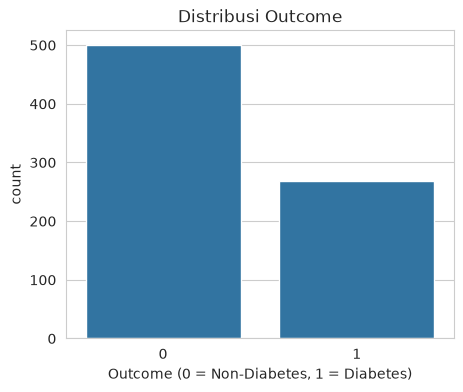

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Outcome')
plt.xlabel('Outcome (0 = Non-Diabetes, 1 = Diabetes)')
plt.show()

print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True) * 100)


Distribusi target (`Outcome`) menunjukkan ketidakseimbangan kelas sedang: 500 pasien (65,10%) berlabel non-diabetes (0) dan 268 pasien (34,90%) berlabel diabetes (1), dengan rasio sekitar 65:35. Ketidakseimbangan ini tidak terlalu ekstrem, namun tetap perlu diperhatikan pada tahap evaluasi karena metrik seperti accuracy saja bisa menyesatkan; precision, recall, dan F1-score pada kelas minoritas (diabetes) menjadi lebih relevan untuk dipantau.



## Distribusi Fitur



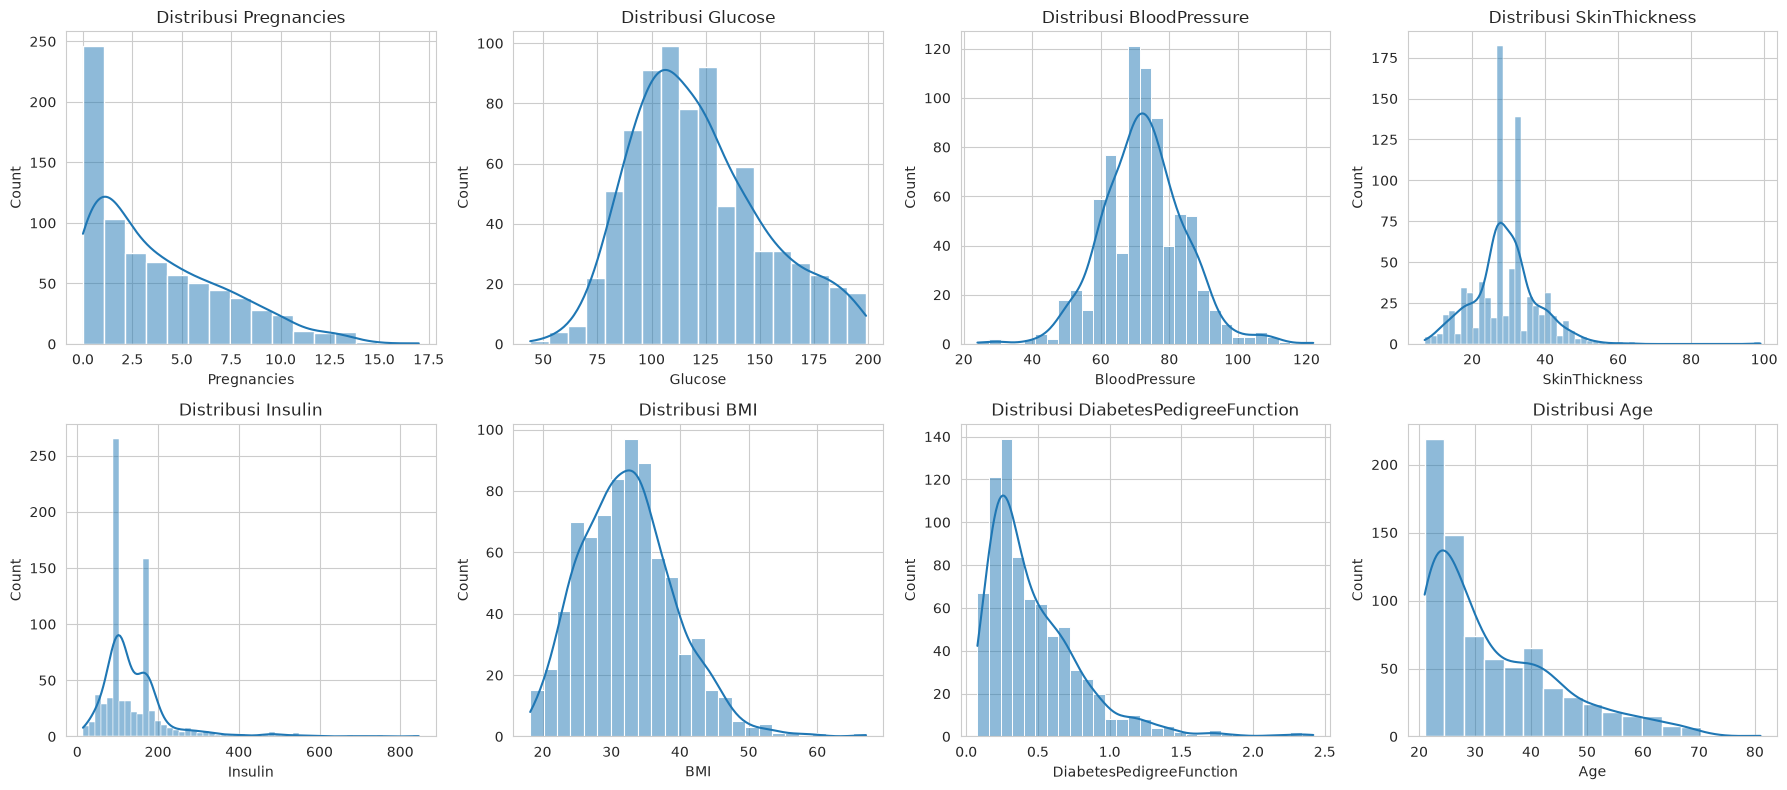

In [8]:
features = [col for col in df.columns if col != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()


Sebagian besar fitur menunjukkan distribusi yang menceng ke kanan (right-skewed), terutama `Insulin` (skewness ≈ 3,03) dan `DiabetesPedigreeFunction` (skewness ≈ 1,92), sementara `Glucose` dan `BloodPressure` relatif mendekati distribusi normal (skewness masing-masing ≈ 0,53 dan ≈ 0,14). Hal ini penting untuk diperhatikan karena Gaussian Naive Bayes mengasumsikan setiap fitur berdistribusi normal di tiap kelas, sehingga fitur dengan skewness tinggi seperti `Insulin` berpotensi melanggar asumsi ini dan dapat menurunkan performa model.



## Outlier Check



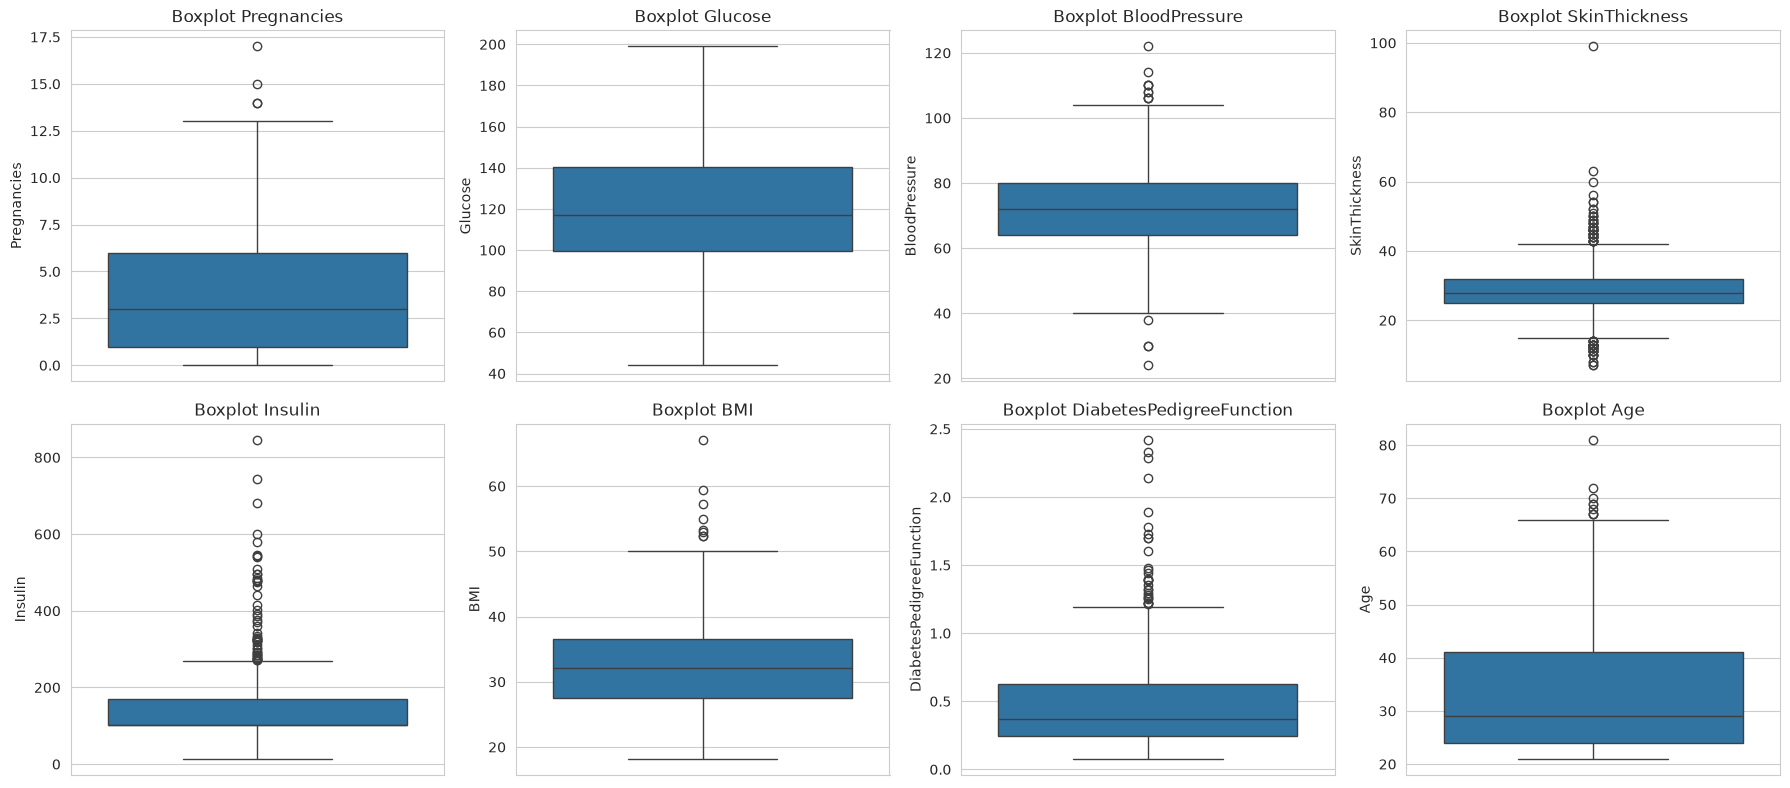

Pregnancies: 4 outlier (0.5%)
Glucose: 0 outlier (0.0%)
BloodPressure: 14 outlier (1.8%)
SkinThickness: 87 outlier (11.3%)
Insulin: 51 outlier (6.6%)
BMI: 8 outlier (1.0%)
DiabetesPedigreeFunction: 29 outlier (3.8%)
Age: 9 outlier (1.2%)


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

for col in features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: {n_outlier} outlier ({n_outlier / len(df) * 100:.1f}%)')


Berdasarkan aturan IQR, `SkinThickness` memiliki proporsi outlier tertinggi (11,3%), diikuti `Insulin` (6,6%) dan `DiabetesPedigreeFunction` (3,8%), sedangkan `Glucose` tidak memiliki outlier sama sekali. Outlier pada `SkinThickness` dan `Insulin` konsisten dengan temuan sebelumnya bahwa sebagian nilainya merupakan hasil imputasi, bukan noise pengukuran murni, sehingga outlier ini tidak akan dibuang, melainkan dibiarkan apa adanya karena kemungkinan tetap merepresentasikan kondisi pasien yang valid (misalnya nilai insulin yang memang tinggi pada pasien diabetes).



## Fitur vs Target



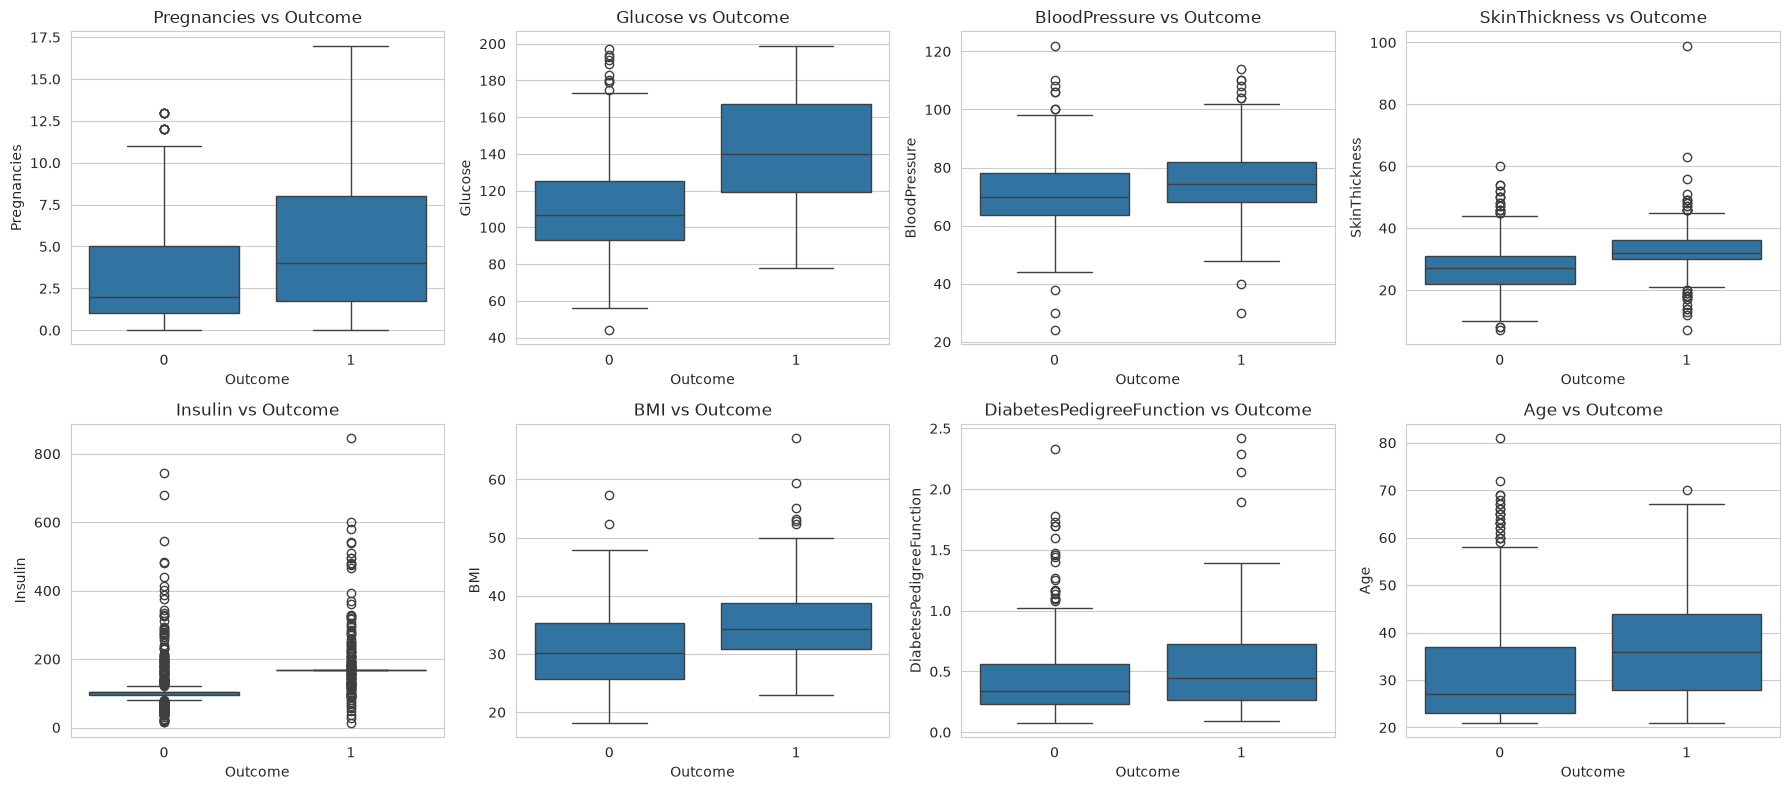

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Outcome')

plt.tight_layout()
plt.show()


Visualisasi fitur terhadap `Outcome` menunjukkan bahwa `Glucose` memiliki pemisahan paling jelas antar kelas: pasien diabetes cenderung memiliki kadar glukosa yang jauh lebih tinggi. `BMI`, `Age`, dan `Insulin` juga menunjukkan pergeseran median yang cukup terlihat antar kelas, sementara `BloodPressure` dan `DiabetesPedigreeFunction` menunjukkan distribusi yang jauh lebih tumpang tindih (overlap) antara kedua kelas, mengindikasikan daya pembeda yang lebih lemah.



## Korelasi Antar Fitur



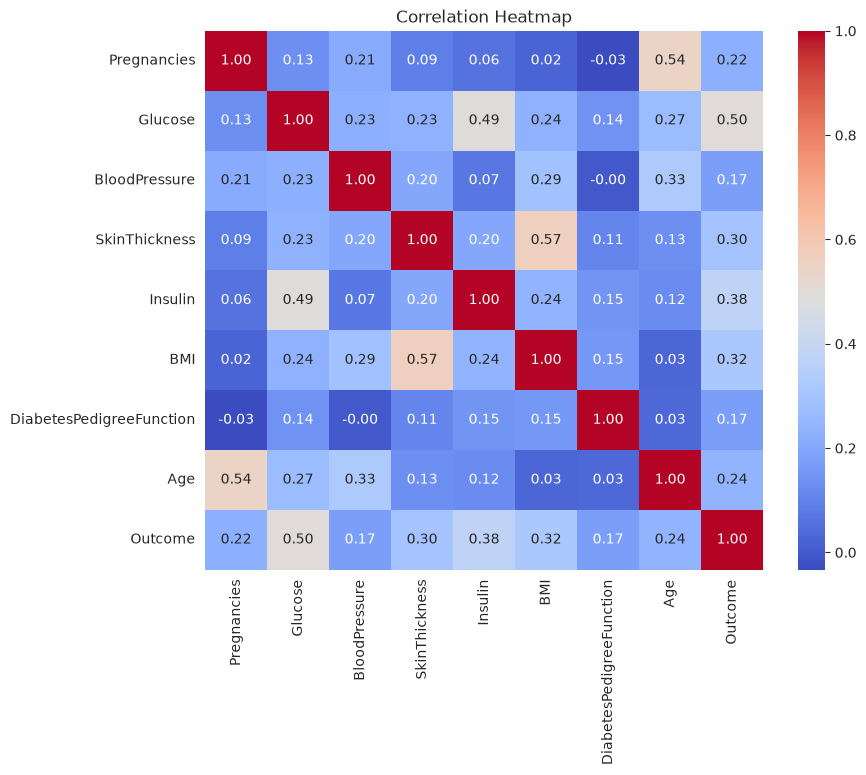

Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64

In [11]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

df.corr()['Outcome'].sort_values(ascending=False)


Fitur yang paling berkorelasi dengan `Outcome` adalah `Glucose` (r ≈ 0,50), diikuti `Insulin` (r ≈ 0,38), `BMI` (r ≈ 0,32), dan `SkinThickness` (r ≈ 0,30), sejalan dengan temuan pada boxplot sebelumnya. `BloodPressure` dan `DiabetesPedigreeFunction` memiliki korelasi paling lemah terhadap target (r ≈ 0,17). Di antar sesama fitur, korelasi tertinggi terlihat antara `SkinThickness` dan `BMI` (keduanya terkait komposisi tubuh) serta `Age` dan `Pregnancies`, namun tidak ada pasangan fitur dengan korelasi yang cukup tinggi untuk mengindikasikan masalah multikolinearitas serius.



## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.



# 2. Preprocessing

Karena seluruh fitur bertipe numerik kontinu dan tidak ada missing value maupun data kategorikal, tahap preprocessing yang dibutuhkan relatif sederhana:

| Model | Kebutuhan Preprocessing |
|---|---|
| Gaussian Naive Bayes | Tidak wajib scaling (invarian terhadap scaling per-fitur), digunakan pada data asli |
| Logistic Regression | Feature scaling (StandardScaler) agar proses optimisasi (gradient-based) stabil dan regularisasi bekerja adil antar fitur |



In [12]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


Train shape: (614, 8)
Test shape : (154, 8)
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Pembagian data dilakukan dengan `train_test_split` (80:20) menggunakan `stratify=y` agar proporsi kelas `Outcome` pada data train dan test tetap konsisten dengan proporsi aslinya (±65:35). `StandardScaler` di-fit hanya pada data train untuk menghindari data leakage, lalu digunakan untuk mentransformasi data test. Gaussian Naive Bayes akan dilatih menggunakan data asli (`X_train`/`X_test`) karena decision boundary-nya tidak berubah akibat scaling per-fitur, sedangkan Logistic Regression akan dilatih menggunakan data yang sudah discaling (`X_train_scaled`/`X_test_scaled`).



# 3. Eksperimen Model



## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.



In [14]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

gnb_predictions = gnb.predict(X_test)
gnb_proba = gnb.predict_proba(X_test)[:, 1]


## 3.2 Logistic Regression



In [15]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

logreg_predictions = logreg.predict(X_test_scaled)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]


In [16]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df


,Feature,Coefficient
1,Glucose,0.934942
4,Insulin,0.614170
5,BMI,0.466051
0,Pregnancies,0.337228
3,SkinThickness,0.294976
6,DiabetesPedigreeFunction,0.174725
7,Age,0.159826
2,BloodPressure,-0.004245


Koefisien Logistic Regression (pada fitur yang sudah discaling) menunjukkan `Glucose` sebagai prediktor positif terkuat (koefisien ≈ 0,93), diikuti `Insulin` (≈ 0,61) dan `BMI` (≈ 0,47), sejalan dengan hasil korelasi pada tahap EDA. `BloodPressure` memiliki koefisien mendekati nol (≈ -0,004), menandakan kontribusinya terhadap prediksi sangat kecil setelah mempertimbangkan fitur lain, konsisten dengan korelasinya yang paling lemah terhadap `Outcome`.



# 4. Evaluasi Model



In [17]:
scores = pd.DataFrame({
    'Model': ['GaussianNB', 'LogisticRegression'],
    'Accuracy': [accuracy_score(y_test, gnb_predictions),
                 accuracy_score(y_test, logreg_predictions)],
    'Precision': [precision_score(y_test, gnb_predictions),
                  precision_score(y_test, logreg_predictions)],
    'Recall': [recall_score(y_test, gnb_predictions),
               recall_score(y_test, logreg_predictions)],
    'F1 Score': [f1_score(y_test, gnb_predictions),
                 f1_score(y_test, logreg_predictions)]
})

scores.set_index('Model', inplace=True)
scores


,Accuracy,Precision,Recall,F1 Score
Model,,,,
GaussianNB,0.727273,0.603448,0.648148,0.625000
LogisticRegression,0.707792,0.588235,0.555556,0.571429


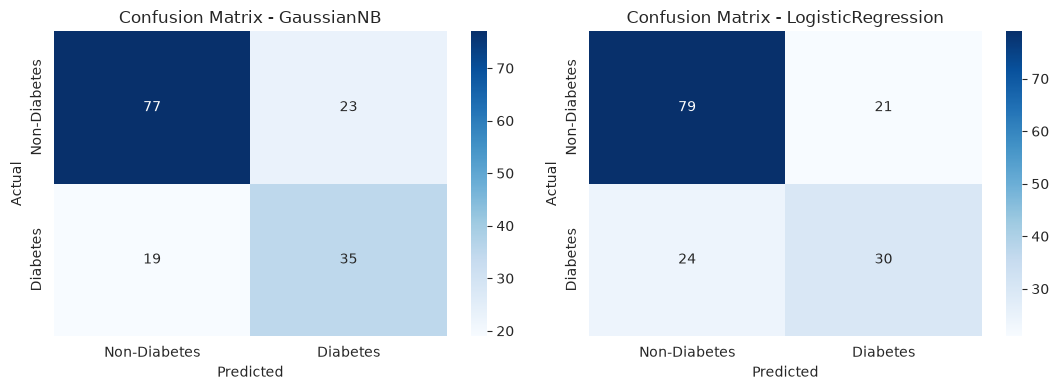

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, pred) in zip(axes, [('GaussianNB', gnb_predictions), ('LogisticRegression', logreg_predictions)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Diabetes', 'Diabetes'],
                yticklabels=['Non-Diabetes', 'Diabetes'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [19]:
print('=== GaussianNB ===')
print(classification_report(y_test, gnb_predictions))
print('=== LogisticRegression ===')
print(classification_report(y_test, logreg_predictions))


=== GaussianNB ===
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



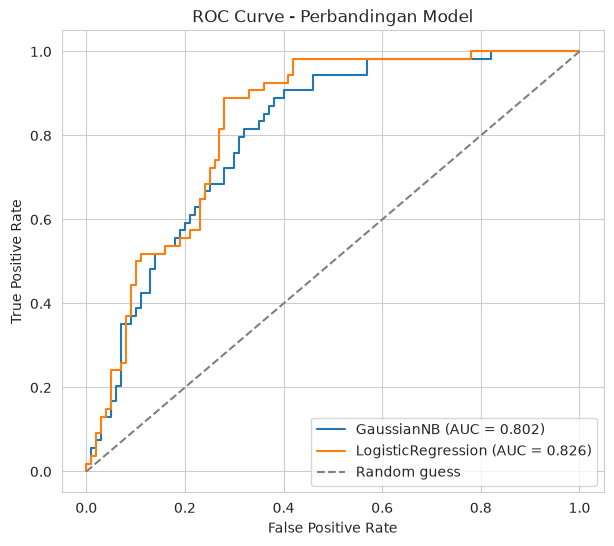

In [20]:
plt.figure(figsize=(7, 6))

models = {
    'GaussianNB': gnb_proba,
    'LogisticRegression': logreg_proba
}

for model_name, y_proba in models.items():
    fpr, tpr, threshold = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Model')
plt.legend()
plt.show()


# 5. Analisis



Berdasarkan hasil evaluasi pada data test, kedua model menunjukkan performa yang cukup dekat namun dengan karakteristik yang berbeda tergantung metrik yang dilihat.

**Perbandingan metrik (threshold default 0,5):**

| Model | Accuracy | Precision | Recall | F1 Score | AUC |
|---|---|---|---|---|---|
| GaussianNB | 0.7273 | 0.6034 | 0.6481 | 0.6250 | 0.8017 |
| LogisticRegression | 0.7078 | 0.5882 | 0.5556 | 0.5714 | 0.8263 |

Pada threshold default (0,5), **GaussianNB justru sedikit unggul** dari Logistic Regression di hampir semua metrik klasifikasi langsung: accuracy (72,73% vs 70,78%), precision (0,6034 vs 0,5882), recall (0,6481 vs 0,5556), dan F1-score (0,6250 vs 0,5714). Dari confusion matrix, GaussianNB berhasil mendeteksi 35 dari 54 pasien diabetes yang sesungguhnya (recall lebih tinggi, false negative lebih sedikit: 19 vs 24 pada Logistic Regression), yang penting dalam konteks medis karena melewatkan pasien diabetes (false negative) lebih berisiko dibanding salah menandai pasien sehat sebagai diabetes (false positive).

Namun ketika dilihat dari **AUC (Area Under ROC Curve)**, urutannya justru terbalik: Logistic Regression memiliki AUC lebih tinggi (0,8263) dibanding GaussianNB (0,8017). Ini menunjukkan bahwa secara keseluruhan, Logistic Regression sebenarnya lebih baik dalam mengurutkan/me-ranking probabilitas pasien diabetes vs non-diabetes di seluruh kemungkinan threshold, meskipun pada threshold default 0,5 performa klasifikasinya sedikit lebih rendah dari GaussianNB. Hal ini mengindikasikan bahwa performa Logistic Regression pada tugas ini kemungkinan dapat ditingkatkan lebih lanjut dengan melakukan tuning threshold (tidak harus 0,5), sedangkan GaussianNB "kebetulan" bekerja cukup baik pada threshold default karena batas keputusannya memang cenderung dekat dengan 0,5 untuk data ini.

Perbedaan pola ini juga bisa dijelaskan dari sisi asumsi model. GaussianNB mengasumsikan setiap fitur berdistribusi normal per kelas dan mengabaikan korelasi antar fitur (independensi kondisional), sebuah asumsi yang cukup dilanggar di sini mengingat pada tahap EDA ditemukan skewness tinggi pada `Insulin` (≈3,03) dan `DiabetesPedigreeFunction` (≈1,92), serta korelasi antar fitur seperti `SkinThickness`-`BMI`. Meski demikian, pelanggaran asumsi ini pada praktiknya tidak selalu menurunkan performa klasifikasi secara drastis, sebagaimana terlihat dari hasil accuracy dan F1-nya yang tetap kompetitif. Logistic Regression, di sisi lain, tidak mengasumsikan independensi antar fitur dan mampu memodelkan kontribusi tiap fitur secara linear terhadap log-odds, dengan `Glucose`, `Insulin`, dan `BMI` sebagai kontributor terbesar sesuai koefisiennya, namun performanya di threshold default sedikit lebih konservatif dalam mendeteksi kelas diabetes (recall lebih rendah).

Secara umum, kedua model mengonfirmasi temuan pada tahap EDA bahwa `Glucose` adalah fitur paling diskriminatif terhadap `Outcome`, diikuti `Insulin` dan `BMI`, sementara `BloodPressure` memberikan kontribusi paling kecil. Performa kedua model yang berada di kisaran accuracy 70-73% dan AUC 0,80-0,83 juga mengindikasikan bahwa dataset ini tidak sepenuhnya separable secara linear/Gaussian sederhana: ada tumpang tindih (overlap) yang cukup besar antar kelas pada ruang fitur yang ada, sebagaimana terlihat pada boxplot fitur vs target di tahap EDA.



# 6. Kesimpulan dan Saran



**Kesimpulan:**
Pada tugas klasifikasi diabetes menggunakan Pima Indians Diabetes Dataset, **GaussianNB memberikan hasil klasifikasi yang sedikit lebih baik pada threshold default** (accuracy 72,73%, F1-score 0,6250) dibanding Logistic Regression (accuracy 70,78%, F1-score 0,5714), namun **Logistic Regression memiliki kemampuan ranking probabilitas yang lebih baik** (AUC 0,8263 vs 0,8017). Tidak ada satu model yang unggul mutlak di semua metrik, sehingga pemilihan model terbaik bergantung pada kebutuhan: jika prioritasnya adalah klasifikasi langsung pada threshold 0,5, GaussianNB lebih disarankan; jika prioritasnya adalah kualitas probabilitas/ranking (misalnya untuk pengambilan keputusan medis bertingkat), Logistic Regression lebih unggul. Kedua model juga sepakat bahwa `Glucose`, `Insulin`, dan `BMI` adalah fitur paling berpengaruh terhadap diagnosis diabetes, sementara `BloodPressure` memberikan kontribusi paling kecil.

**Saran untuk eksperimen selanjutnya:**
1. **Tuning threshold klasifikasi**, khususnya untuk Logistic Regression yang memiliki AUC lebih tinggi namun performa pada threshold 0,5 masih di bawah GaussianNB, menggeser threshold dapat meningkatkan recall pada kelas diabetes yang secara medis lebih penting untuk diminimalkan false negative-nya.
2. **Menangani skewness dan outlier pada `Insulin` dan `SkinThickness`** (misalnya dengan transformasi log) sebelum melatih GaussianNB, mengingat kedua fitur ini melanggar asumsi normalitas yang mendasari model tersebut.
3. **Menambahkan regularisasi atau tuning hyperparameter** (misalnya parameter `C` pada Logistic Regression) melalui cross-validation untuk melihat apakah performa dapat ditingkatkan lebih lanjut.
4. **Menangani class imbalance** (65:35) dengan teknik seperti class weighting atau resampling (SMOTE), mengingat recall pada kelas minoritas (diabetes) masih relatif rendah pada kedua model.
5. **Mencoba model pembanding lain** (misalnya Random Forest atau Gradient Boosting) untuk melihat apakah hubungan non-linear antar fitur dapat menangkap pola yang terlewat oleh GaussianNB dan Logistic Regression, mengingat AUC kedua model masih berada di kisaran 0,80-0,83 (belum mendekati sempurna).
